In [1]:
# Copyright (c) Meta Platforms, Inc. and affiliates.
# Lightly adapted from https://github.com/facebookresearch/segment-anything/blob/main/notebooks/automatic_mask_generator_example.ipynb

In [1]:
import os
# if using Apple MPS, fall back to CPU for unsupported ops
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from sklearn.metrics import accuracy_score, f1_score, jaccard_score, recall_score, precision_score
import pandas as pd
import time

In [2]:
# select the device for computation
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"using device: {device}")

if device.type == "cuda":
    # use bfloat16 for the entire notebook
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    # turn on tfloat32 for Ampere GPUs (https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices)
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
elif device.type == "mps":
    print(
        "\nSupport for MPS devices is preliminary. SAM 2 is trained with CUDA and might "
        "give numerically different outputs and sometimes degraded performance on MPS. "
        "See e.g. https://github.com/pytorch/pytorch/issues/84936 for a discussion."
    )

using device: cpu


In [3]:
np.random.seed(3)

def show_anns(anns, borders=True):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:, :, 3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.5]])
        img[m] = color_mask 
        if borders:
            import cv2
            contours, _ = cv2.findContours(m.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE) 
            # Try to smooth contours
            contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
            cv2.drawContours(img, contours, -1, (0, 0, 1, 0.4), thickness=1) 

    ax.imshow(img)

In [4]:
# load new images
path = "C:/Users/syj43/q_seg/datasets/spheroidite_particles/"
image_files = [f for f in os.listdir(path+"image_patches/")]
label_files = [f for f in os.listdir(path+"label_patches/")]
images = [cv2.imread(path+"image_patches/"+f, cv2.IMREAD_GRAYSCALE) for f in image_files]
masks = [cv2.imread(path+"label_patches/"+f, cv2.IMREAD_GRAYSCALE) for f in label_files]

images, labels = [], []
for i in range(len(images)):
    # image = cv2.imread(img_path + image_files[i], cv2.COLOR_BGR2RGB)
    image = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)
    images.append(image)
    label = cv2.imread(masks[i], cv2.IMREAD_GRAYSCALE) / 255.0
    labels.append(label)

In [5]:
path = "C:/Users/syj43/q_seg/datasets/spheroidite_particles/"
img_folder = path + "image_patches/"
lbl_folder = path + "label_patches/"

image_files = sorted([f for f in os.listdir(img_folder) if not f.startswith('.')])
label_files = sorted([f for f in os.listdir(lbl_folder) if not f.startswith('.')])

images = []
labels = []

for i in range(len(image_files)):
    # Read color image (3-channel) and convert BGR to RGB
    img = cv2.imread(img_folder + image_files[i], cv2.IMREAD_COLOR)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    images.append(img_rgb)

    # Read label (1-channel grayscale) and normalize to [0, 1]
    lbl = cv2.imread(lbl_folder + label_files[i], cv2.IMREAD_GRAYSCALE) / 255.0
    labels.append(lbl)

In [6]:
from sam2.build_sam import build_sam2
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator

sam2_checkpoint = "../checkpoints/sam2.1_hiera_large.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_l.yaml"

sam2 = build_sam2(model_cfg, sam2_checkpoint, device=device, apply_postprocessing=False)

mask_generator = SAM2AutomaticMaskGenerator(sam2)

In [7]:
def show_all_masks(masks):
    # Suppose masks is a list of dictionaries, each with a 'segmentation' key
    num_masks = len(masks)

    # Create a grid layout (adjust cols/rows as needed)
    cols = 4
    rows = (num_masks + cols - 1) // cols  # ceiling division

    fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))

    # Flatten axes for easy iteration
    axes = axes.flatten()

    for i, ax in enumerate(axes):
        if i < num_masks:
            ax.imshow(masks[i]['segmentation'])
            ax.set_title(f"Mask {i}")
            ax.axis("off")
        else:
            ax.axis("off")  # hide unused subplots

    plt.tight_layout()
    plt.show()

Sample run

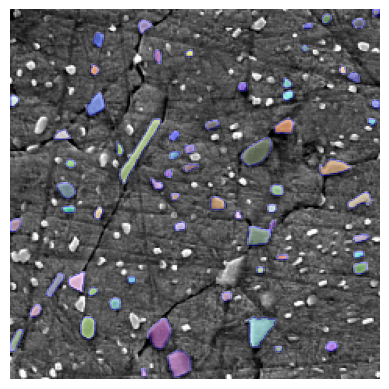

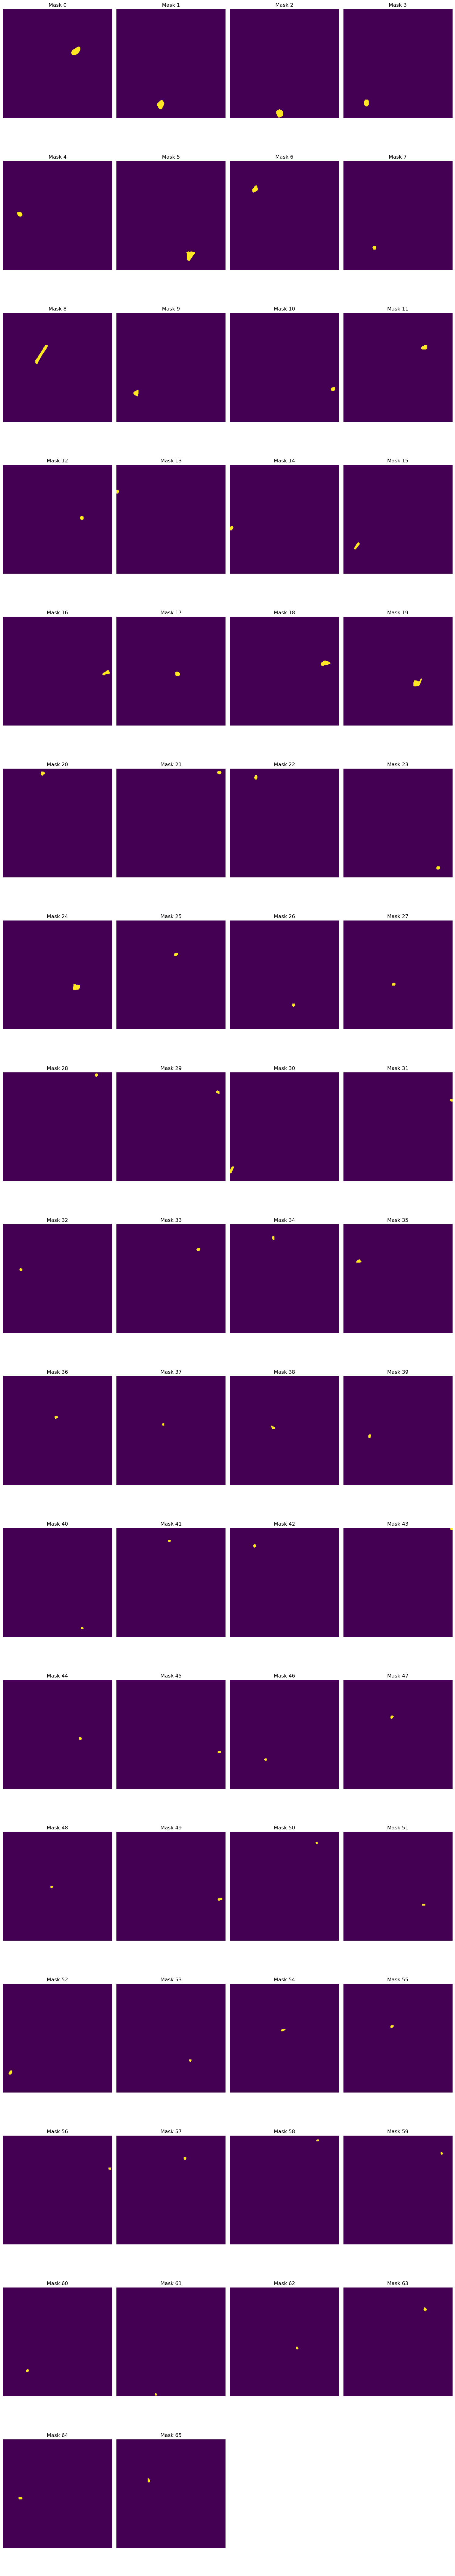

In [8]:
idx = 0
image = images[idx]
plt.imshow(image)
masks = mask_generator.generate(image)
show_anns(masks)
plt.axis('off')
plt.show()

show_all_masks(masks)

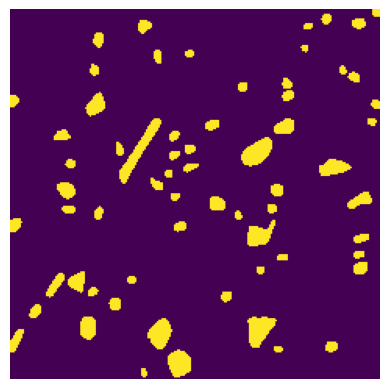

In [9]:
combined_mask = np.logical_or.reduce([item['segmentation'] for item in masks])
plt.imshow(combined_mask)
plt.axis('off')
plt.show()

In [10]:
def get_metrics(labels, idx, masks):
    """combine small masks and compare it with ground truth"""
    y_true = labels[idx].astype(int).ravel()
    # y_pred = np.logical_or.reduce([item['segmentation'] for item in masks]).astype(int).ravel()
    # Compute total number of pixels once
    threshold = 0.5 * masks[0]['segmentation'].size
    filtered_segmentations = [
        item['segmentation']
        for item in masks
        if item['segmentation'].sum() <= threshold
    ]
    if filtered_segmentations:
        y_pred = (
            np.logical_or.reduce(filtered_segmentations).astype(int).ravel()
        )
    else:
        y_pred = np.zeros(masks[0]['segmentation'].shape, dtype=int).ravel()
    accuracy = round(accuracy_score(y_true, y_pred), 3)
    iou = round(jaccard_score(y_true, y_pred, average='macro',  zero_division=1), 3)
    precision = round(precision_score(y_true, y_pred, average='macro', zero_division=1), 3)
    recall = round(recall_score(y_true, y_pred, average='macro', zero_division=1), 3)
    f1 = round(f1_score(y_true, y_pred, average='macro',  zero_division=1), 3)
    return [accuracy, iou, precision, recall, f1]

get_metrics(labels, 0, masks)

[0.936, 0.699, 0.843, 0.769, 0.8]

End of the sample run

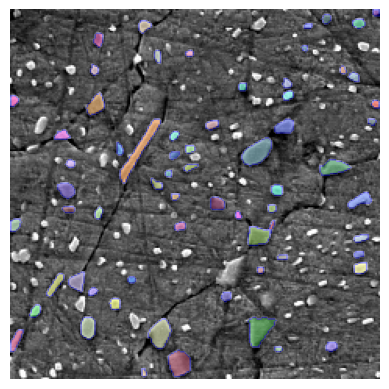

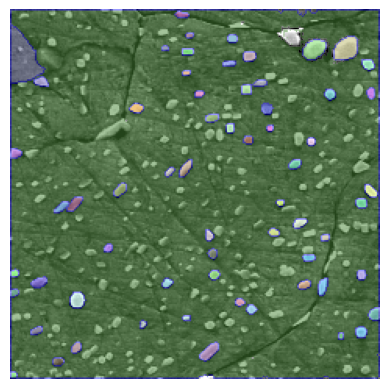

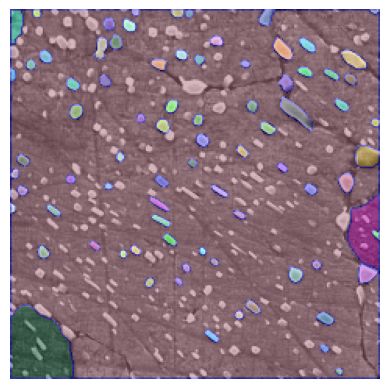

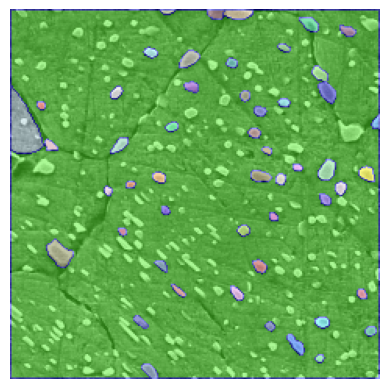

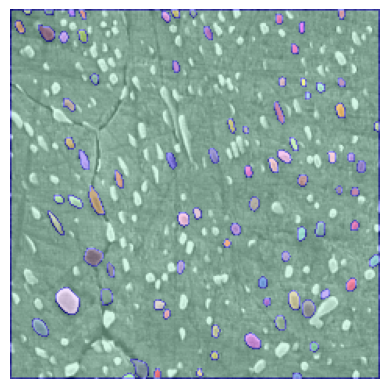

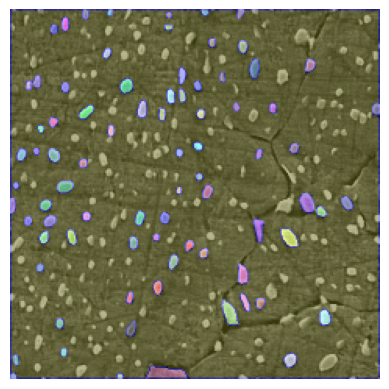

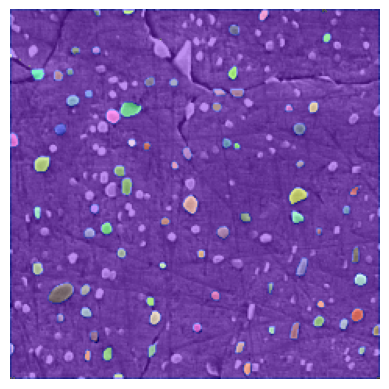

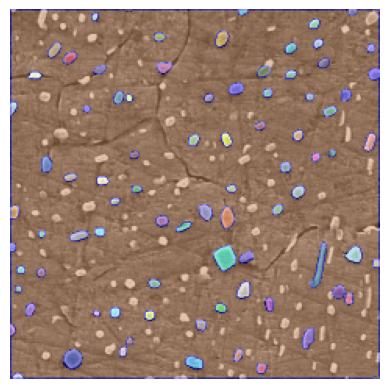

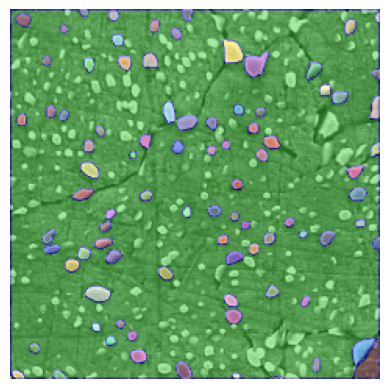

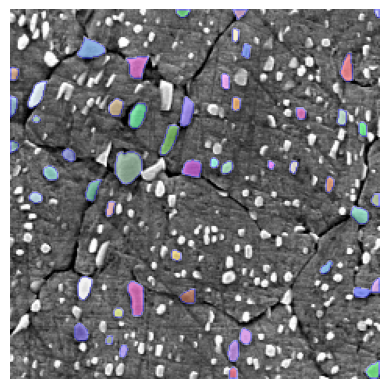

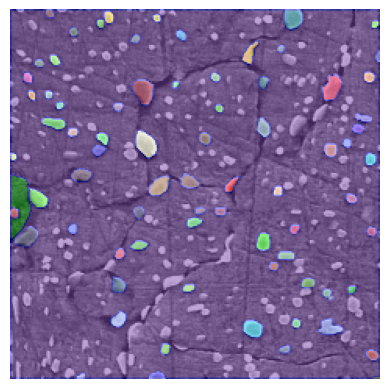

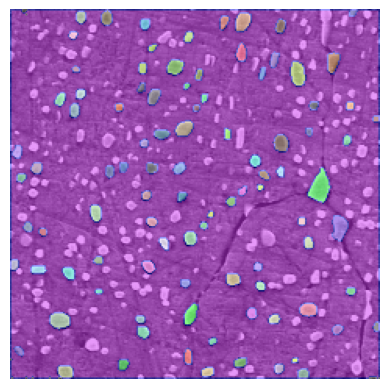

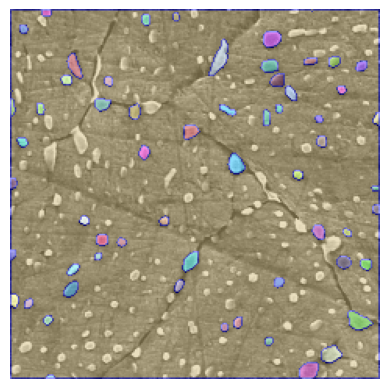

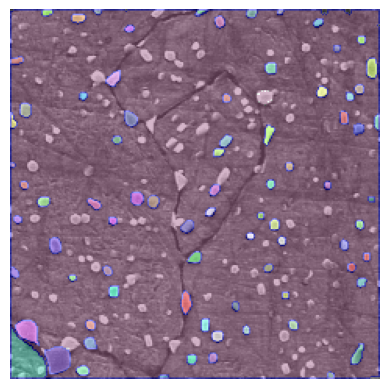

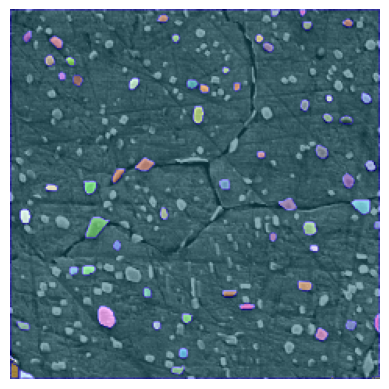

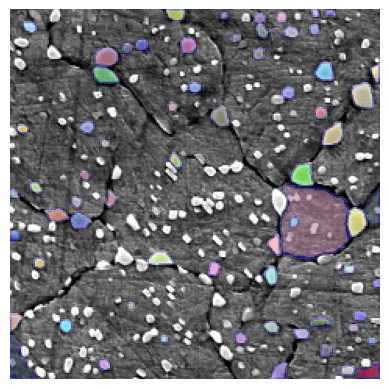

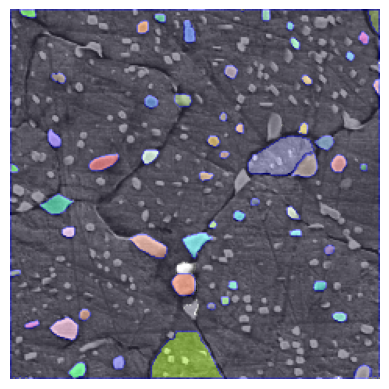

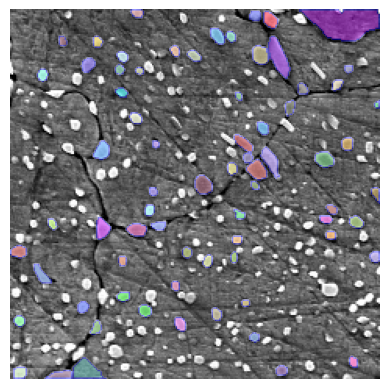

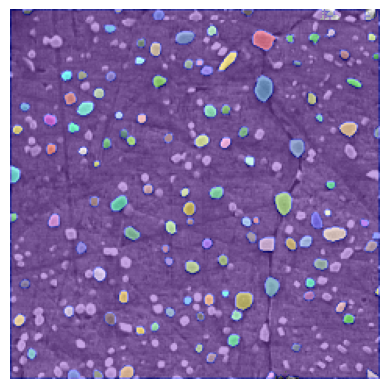

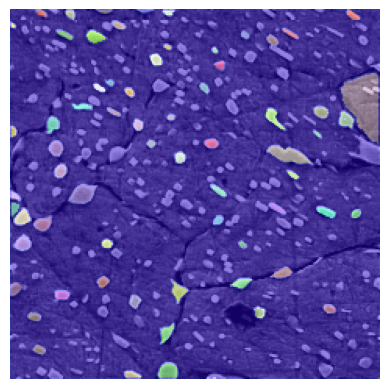

,idx,Accuracy,IoU,Precision,Recall,F1,Runtime
0,0.0,0.936,0.699,0.843,0.769,0.800,32.478
1,1.0,0.909,0.610,0.799,0.674,0.714,31.852
2,2.0,0.858,0.579,0.719,0.680,0.696,32.157
3,3.0,0.884,0.579,0.795,0.647,0.685,30.869
4,4.0,0.908,0.640,0.868,0.699,0.749,33.247
5,5.0,0.916,0.640,0.845,0.699,0.746,33.957
6,6.0,0.927,0.667,0.853,0.726,0.771,38.398
7,7.0,0.931,0.687,0.857,0.749,0.790,34.312
8,8.0,0.890,0.637,0.831,0.710,0.750,32.241
9,9.0,0.892,0.624,0.877,0.687,0.736,32.555


In [11]:
df = pd.DataFrame(columns=['idx', 'Accuracy', 'IoU', 'Precision', 'Recall', 'F1', 'Runtime'])
l_runtime = []

for i in range(20):
    image = images[i]
    
    start = time.time()
    masks = mask_generator.generate(image)
    end = time.time()
    
    plt.imshow(image)
    show_anns(masks)
    plt.axis('off')
    plt.show()
    
    df.loc[len(df)] = [i] + get_metrics(labels, i, masks) + [round(end-start,3)]

df

In [12]:
df.to_csv('spherodite_eval_sam.csv')

In [13]:
df.describe().loc[['mean', '50%']].round(3)

,idx,Accuracy,IoU,Precision,Recall,F1,Runtime
mean,9.5,0.902,0.634,0.821,0.704,0.742,32.752
50%,9.5,0.904,0.632,0.830,0.699,0.742,32.385


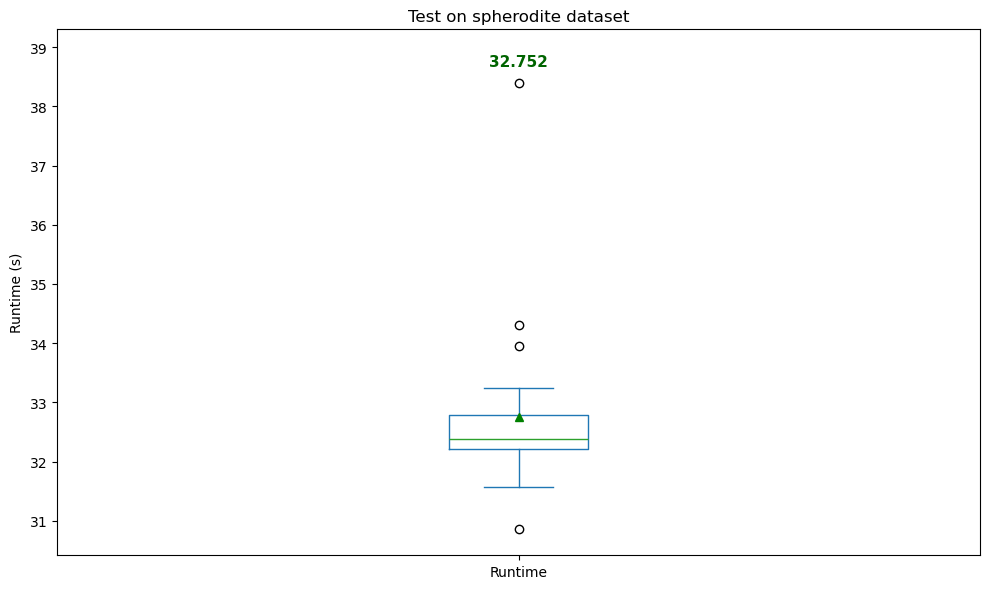

In [17]:
if 'idx' in df.columns:
    df_runtime = df.set_index('idx')

df_runtime = df_runtime[['Runtime']]

# 1. Generate boxplot with mean markers
ax = df_runtime.plot(
    kind="box",
    figsize=(10, 6),
    showmeans=True,
    meanprops={
        "marker": "^",
        "markerfacecolor": "green",
        "markeredgecolor": "green",
    },
)

# Offset to lift text above the top whisker/outliers
y_offset = (df_runtime.values.max() - df_runtime.values.min()) * 0.03

# 2. Iterate through columns and place text above each box
for i, col in enumerate(df_runtime.columns, start=1):
    mean_val = df_runtime[col].mean()
    max_val = df_runtime[col].max()  # Positions above the highest point of the column

    ax.text(
        x=i,
        y=max_val + y_offset,
        s=f"{mean_val:.3f}",
        horizontalalignment="center",
        verticalalignment="bottom",
        fontsize=11,
        color="darkgreen",
        fontweight="bold",
    )

# Adjust y-limit slightly so top text doesn't get clipped by the frame
ax.set_ylim(df_runtime.values.min() - y_offset * 2, df_runtime.values.max() + y_offset * 4)

plt.grid(False)
plt.title("Test on spherodite dataset")
plt.ylabel("Runtime (s)")
plt.tight_layout()
plt.show()

In [ ]:
df.drop(columns=['idx', 'Runtime'], inplace=True)

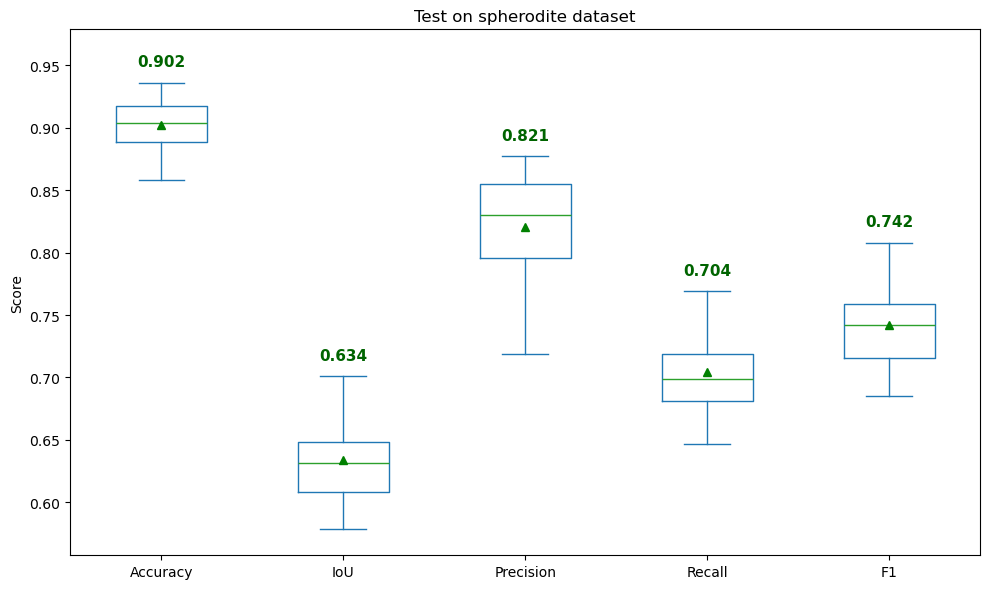

In [ ]:
# 1. Generate boxplot with mean markers
ax = df.plot(
    kind="box",
    figsize=(10, 6),
    showmeans=True,
    meanprops={
        "marker": "^",
        "markerfacecolor": "green",
        "markeredgecolor": "green",
    },
)

# Offset to lift text above the top whisker/outliers
y_offset = (df.values.max() - df.values.min()) * 0.03

# 2. Iterate through columns and place text above each box
for i, col in enumerate(df.columns, start=1):
    mean_val = df[col].mean()
    max_val = df[col].max()  # Positions above the highest point of the column

    ax.text(
        x=i,
        y=max_val + y_offset,
        s=f"{mean_val:.3f}",
        horizontalalignment="center",
        verticalalignment="bottom",
        fontsize=11,
        color="darkgreen",
        fontweight="bold",
    )

# Adjust y-limit slightly so top text doesn't get clipped by the frame
ax.set_ylim(df.values.min() - y_offset * 2, df.values.max() + y_offset * 4)

plt.grid(False)
plt.title("Test on spherodite dataset")
plt.ylabel("Score")
plt.tight_layout()
plt.show()